# Human Activity Recognition Using Hidden Markov Models
**Course:** Machine Learning Technique 2 (MLT2)  
**Assignment:** Formative 2  
**Student:** Jok John Maker Kur  
**Institution:** African Leadership University  
**Date:** June 2026  

---

## 1. Background and Motivation

Human activity recognition (HAR) is a fundamental problem in ubiquitous computing,
with applications ranging from wearable health monitors to smart home systems. In these
systems, the true activity state such as walking or standing is hidden behind noisy
sensor measurements, making Hidden Markov Models (HMMs) a natural fit for modelling
the underlying sequential behaviour.

This project collects real motion sensor data using the Sensor Logger app on an Android
device, recording accelerometer and gyroscope signals across four activities: still,
standing, walking, and jumping. A Gaussian HMM is then trained to infer the hidden
activity states from extracted time-domain and frequency-domain features, with the
Baum–Welch algorithm for training and Viterbi decoding for inference.

---

## 2. Data Collection and Preprocessing

### 2.1 Data Loading and Merging
Each recording session produces two separate CSV files one for the accelerometer
and one for the gyroscope both sampled at approximately 100 Hz. Files are merged
on the `time` column to produce a single aligned dataframe per recording.


### 2.2 Library Imports and Setup

In [5]:
# Install hmmlearn
!pip install hmmlearn -q

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


### 2.2 Data Loading and Merging

Each recording produces two CSV files — accelerometer and gyroscope — sampled at approximately 100 Hz. Files are merged on the `time` column to produce a single aligned dataframe per recording. The four activity labels are encoded as integers for use in the HMM.

| Activity | Label |
|---|---|
| Still | 0 |
| Standing | 1 |
| Walking | 2 |
| Jumping | 3 |

In [6]:
# Clone repo and navigate into it
!git clone https://github.com/JokMaker/hmm-activity-recognition.git
import os
os.chdir('hmm-activity-recognition')

# Activity label mapping
ACTIVITIES = {
    'still': 0,
    'standing': 1,
    'walking': 2,
    'jumping': 3
}

def load_recording(acc_path, gyro_path):
    """Load and merge accelerometer and gyroscope CSV files."""
    acc = pd.read_csv(acc_path)
    gyro = pd.read_csv(gyro_path)

    # Rename columns to avoid conflicts
    acc = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    gyro = gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    # Merge on nearest time
    merged = pd.merge_asof(
        acc.sort_values('time'),
        gyro[['time', 'gyro_x', 'gyro_y', 'gyro_z']].sort_values('time'),
        on='time',
        direction='nearest'
    )
    return merged.dropna()

def load_all_data(base_path='data/train'):
    """Load all recordings from all activity folders."""
    all_data = []
    for activity, label in ACTIVITIES.items():
        folder = os.path.join(base_path, activity)
        acc_files = sorted([f for f in os.listdir(folder) if 'accelerometer' in f])
        for acc_file in acc_files:
            num = acc_file.split('_')[1]
            gyro_file = f"{activity}_{num}_gyroscope.csv"
            acc_path = os.path.join(folder, acc_file)
            gyro_path = os.path.join(folder, gyro_file)
            if os.path.exists(gyro_path):
                df = load_recording(acc_path, gyro_path)
                df['activity'] = activity
                df['label'] = label
                all_data.append(df)
    print(f"Loaded {len(all_data)} recordings successfully!")
    return all_data

all_recordings = load_all_data()

Cloning into 'hmm-activity-recognition'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 119 (delta 25), reused 116 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 2.07 MiB | 17.66 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Loaded 50 recordings successfully!


### 2.3 Data Visualization

Sample raw sensor signals are plotted for each activity to visually confirm the quality and distinctiveness of the recorded data.

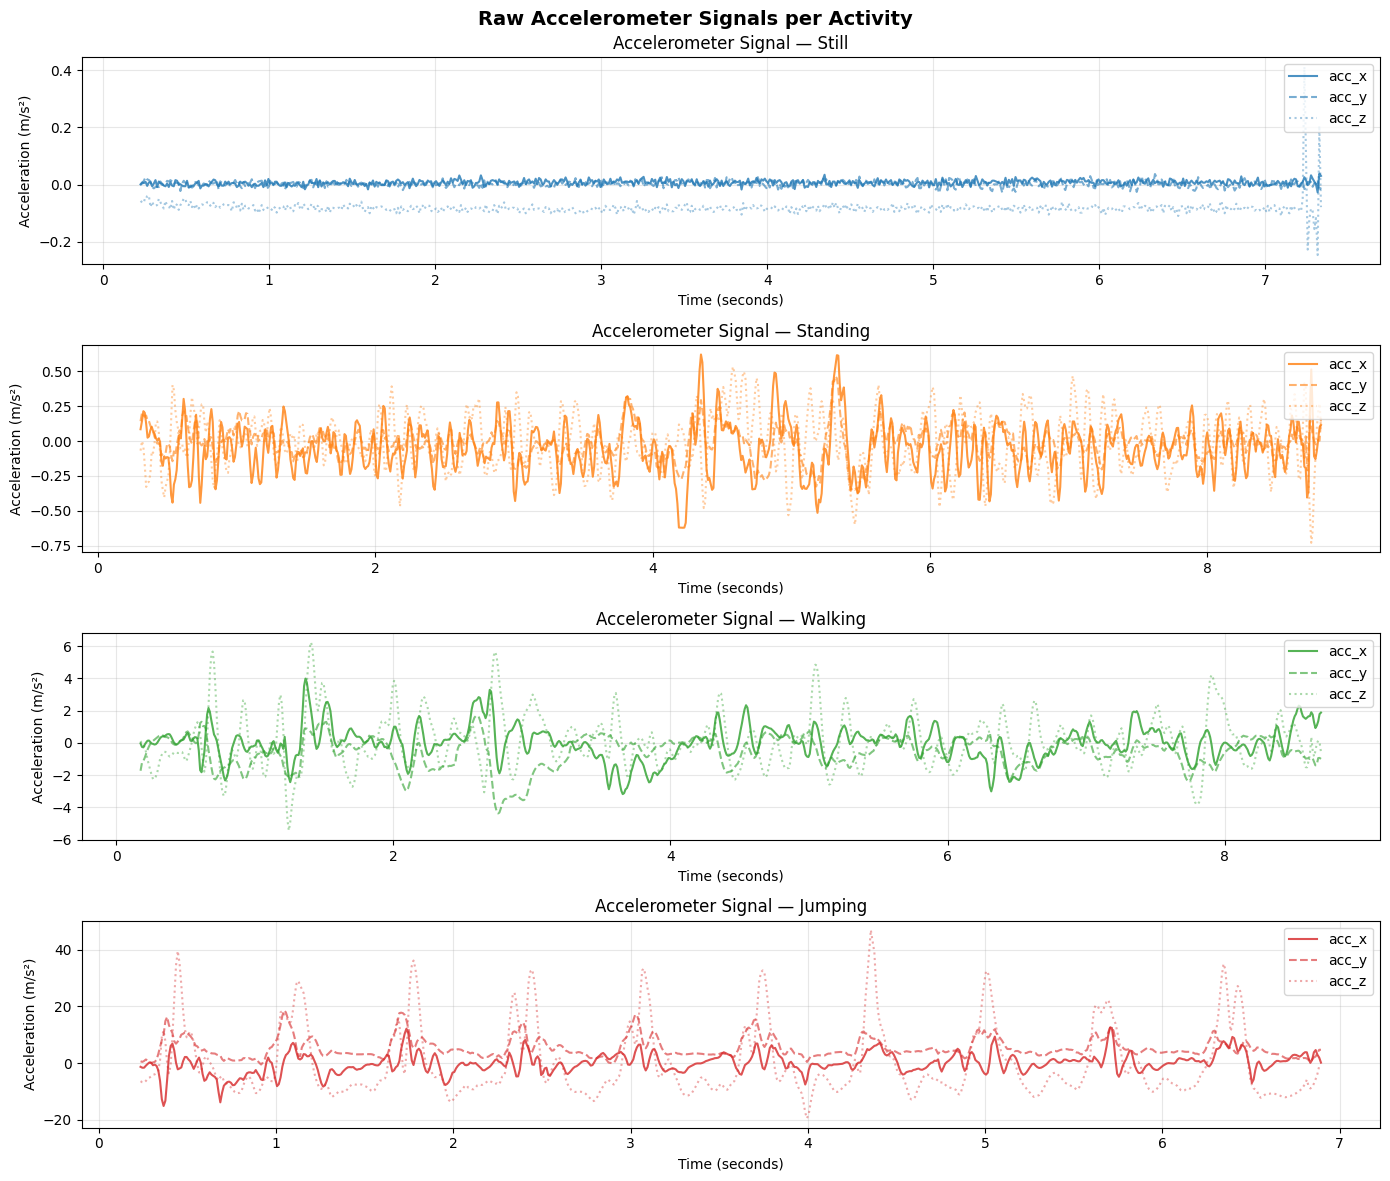

Raw signal plots saved!


In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
activities_to_plot = ['still', 'standing', 'walking', 'jumping']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, activity in enumerate(activities_to_plot):
    # Get first recording of each activity
    recording = [r for r in all_recordings if r['activity'].iloc[0] == activity][0]
    axes[i].plot(recording['seconds_elapsed'], recording['acc_x'],
                 label='acc_x', alpha=0.8, color=colors[i])
    axes[i].plot(recording['seconds_elapsed'], recording['acc_y'],
                 label='acc_y', alpha=0.6, linestyle='--', color=colors[i])
    axes[i].plot(recording['seconds_elapsed'], recording['acc_z'],
                 label='acc_z', alpha=0.4, linestyle=':', color=colors[i])
    axes[i].set_title(f'Accelerometer Signal — {activity.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Time (seconds)')
    axes[i].set_ylabel('Acceleration (m/s²)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Raw Accelerometer Signals per Activity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Raw signal plots saved!")

## 3. Feature Extraction

### 3.1 Windowing Strategy
Each recording is divided into fixed-size windows of 100 samples (1 second at 100 Hz). This window size was chosen because 1 second is sufficient to capture one full gait cycle for walking and one full jump, while remaining short enough to detect activity transitions.

### 3.2 Time-Domain and Frequency-Domain Features
For each window, the following features are extracted:
- **Time-domain:** mean, variance, standard deviation, Signal Magnitude Area (SMA), inter-axis correlation
- **Frequency-domain:** dominant frequency and spectral energy via FFT

All features are normalised using Z-score standardisation.

In [8]:
WINDOW_SIZE = 100  # 1 second at 100 Hz
SAMPLING_RATE = 100

def extract_features(window):
    """Extract time-domain and frequency-domain features from a window."""
    features = []
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    # Time-domain features
    for ax in axes:
        sig = window[ax].values
        features.append(np.mean(sig))           # mean
        features.append(np.var(sig))            # variance
        features.append(np.std(sig))            # standard deviation

    # Signal Magnitude Area (SMA)
    sma = np.sum(np.abs(window['acc_x'].values) +
                 np.abs(window['acc_y'].values) +
                 np.abs(window['acc_z'].values)) / WINDOW_SIZE
    features.append(sma)

    # Inter-axis correlation (acc_x vs acc_y, acc_y vs acc_z)
    corr_xy, _ = pearsonr(window['acc_x'].values, window['acc_y'].values)
    corr_yz, _ = pearsonr(window['acc_y'].values, window['acc_z'].values)
    features.append(corr_xy)
    features.append(corr_yz)

    # Frequency-domain features (FFT on acc_x)
    sig = window['acc_x'].values
    fft_vals = np.abs(fft(sig))[:WINDOW_SIZE // 2]
    freqs = fftfreq(WINDOW_SIZE, d=1/SAMPLING_RATE)[:WINDOW_SIZE // 2]
    dominant_freq = freqs[np.argmax(fft_vals)]
    spectral_energy = np.sum(fft_vals ** 2) / WINDOW_SIZE
    features.append(dominant_freq)
    features.append(spectral_energy)

    return features

def create_windows(recordings, window_size=WINDOW_SIZE):
    """Slide a window over each recording and extract features."""
    X, y, lengths = [], [], []
    for recording in recordings:
        rec_features = []
        n = len(recording)
        for start in range(0, n - window_size + 1, window_size):
            window = recording.iloc[start:start + window_size]
            if len(window) == window_size:
                features = extract_features(window)
                rec_features.append(features)
                y.append(recording['label'].iloc[0])
        if rec_features:
            X.extend(rec_features)
            lengths.append(len(rec_features))
    return np.array(X), np.array(y), lengths

X_raw, y, lengths = create_windows(all_recordings)
print(f"Feature matrix shape: {X_raw.shape}")
print(f"Number of windows: {len(y)}")
print(f"Features per window: {X_raw.shape[1]}")
print(f"Class distribution: { {k: int(np.sum(y == v)) for k, v in ACTIVITIES.items()} }")

Feature matrix shape: (330, 23)
Number of windows: 330
Features per window: 23
Class distribution: {'still': 77, 'standing': 95, 'walking': 85, 'jumping': 73}


### 3.3 Feature Normalisation
All features are normalised using Z-score standardisation (zero mean, unit variance) to ensure no single feature dominates the HMM emission probabilities due to scale differences.

Normalisation complete!
Mean of normalised features (should be ~0): [ 0. -0. -0.  0.  0.]
Std of normalised features (should be ~1): [1. 1. 1. 1. 1.]


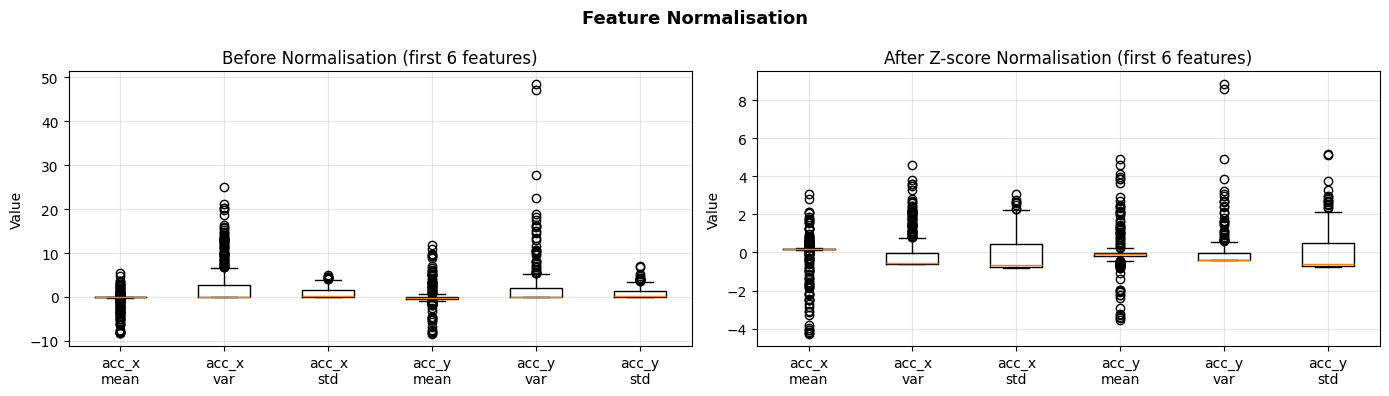

Normalisation plot saved!


In [9]:
# Z-score normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Normalisation complete!")
print(f"Mean of normalised features (should be ~0): {X.mean(axis=0)[:5].round(4)}")
print(f"Std of normalised features (should be ~1): {X.std(axis=0)[:5].round(4)}")

# Plot feature distributions before and after normalisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(X_raw[:, :6], labels=['acc_x\nmean', 'acc_x\nvar', 'acc_x\nstd',
                                       'acc_y\nmean', 'acc_y\nvar', 'acc_y\nstd'])
axes[0].set_title('Before Normalisation (first 6 features)')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(X[:, :6], labels=['acc_x\nmean', 'acc_x\nvar', 'acc_x\nstd',
                                   'acc_y\nmean', 'acc_y\nvar', 'acc_y\nstd'])
axes[1].set_title('After Z-score Normalisation (first 6 features)')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature Normalisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('normalisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Normalisation plot saved!")

## 4. HMM Setup and Implementation

### 4.1 Model Definition
The HMM is defined with the following components:

| Component | Description |
|---|---|
| Hidden States (Z) | 4 activities: still, standing, walking, jumping |
| Observations (X) | 23-dimensional feature vectors per window |
| Transition Matrix (A) | Probability of moving from one activity to another |
| Emission Probabilities (B) | Gaussian distributions over feature vectors per state |
| Initial State Probabilities (π) | Uniform initialisation across all 4 states |

### 4.2 Baum–Welch Training
The model is trained using the Baum–Welch algorithm with a log-likelihood convergence criterion. Training stops when the change in log-likelihood between iterations falls below ε = 1e-4, ensuring the model has converged rather than using a fixed iteration count.

Model converged: True
Iterations run: 5
Final log-likelihood: 5565.0260


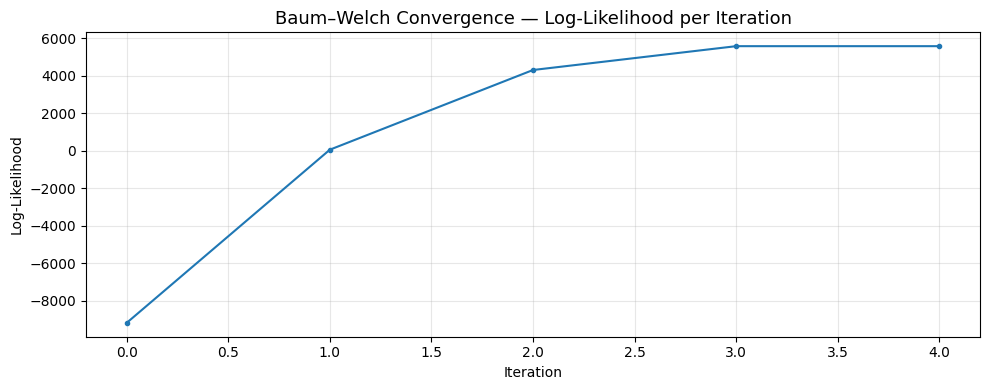

Convergence plot saved!


In [10]:
N_STATES = 4
CONVERGENCE_THRESH = 1e-4
MAX_ITER = 200

# Train HMM using Baum-Welch
model = GaussianHMM(
    n_components=N_STATES,
    covariance_type='diag',
    n_iter=MAX_ITER,
    tol=CONVERGENCE_THRESH,
    verbose=False,
    random_state=42
)

model.fit(X, lengths)

# Check convergence
log_likelihoods = model.monitor_.history
print(f"Model converged: {model.monitor_.converged}")
print(f"Iterations run: {len(log_likelihoods)}")
print(f"Final log-likelihood: {log_likelihoods[-1]:.4f}")

# Plot convergence
plt.figure(figsize=(10, 4))
plt.plot(log_likelihoods, marker='o', markersize=3, color='#1f77b4')
plt.title('Baum–Welch Convergence — Log-Likelihood per Iteration', fontsize=13)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plot saved!")

### 4.3 Transition Matrix and Emission Probabilities

The learned transition matrix shows the probability of moving from one activity state to another. The emission probability matrix shows how strongly each hidden state associates with each observation feature.

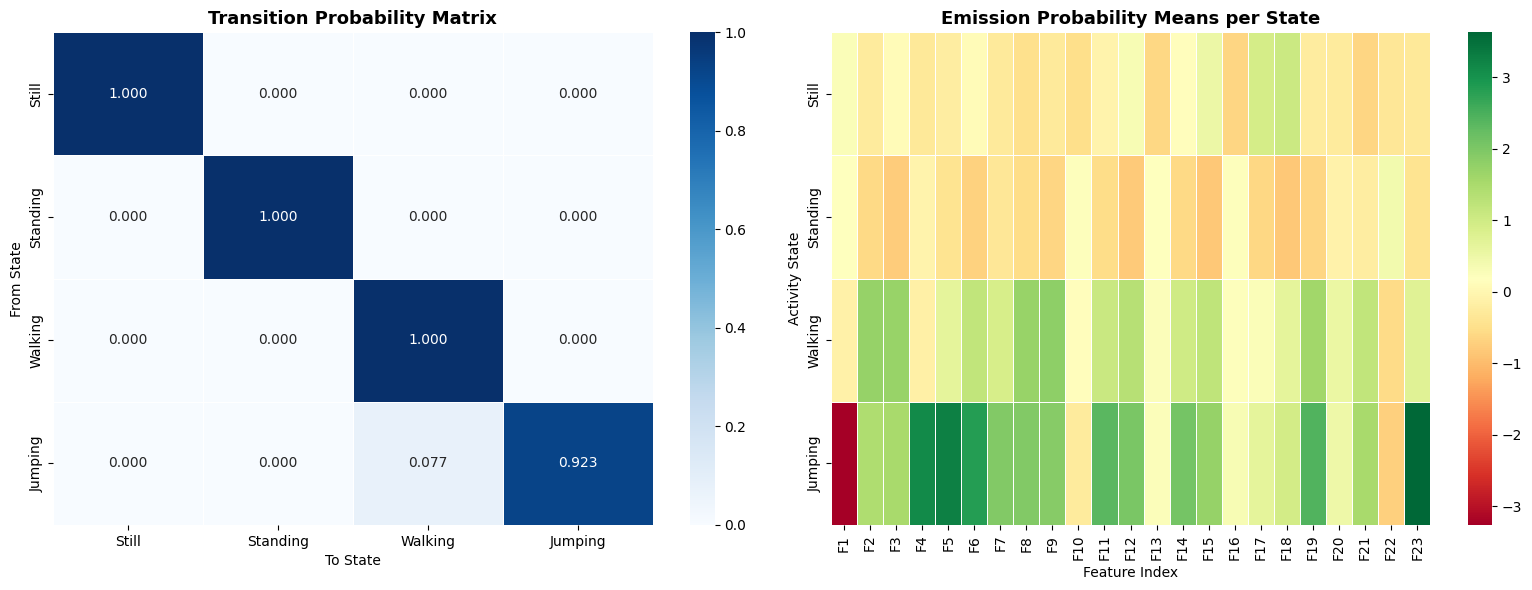

Transition and emission plots saved!


In [11]:
activity_names = ['Still', 'Standing', 'Walking', 'Jumping']

# Plot transition matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    model.transmat_,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=activity_names,
    yticklabels=activity_names,
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Transition Probability Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('To State')
axes[0].set_ylabel('From State')

# Plot emission means (one row per state, one col per feature)
sns.heatmap(
    model.means_,
    cmap='RdYlGn',
    xticklabels=[f'F{i+1}' for i in range(X.shape[1])],
    yticklabels=activity_names,
    ax=axes[1],
    linewidths=0.5,
    annot=False
)
axes[1].set_title('Emission Probability Means per State', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Activity State')

plt.tight_layout()
plt.savefig('transition_emission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Transition and emission plots saved!")

## 5. Viterbi Decoding

The Viterbi algorithm decodes the most likely sequence of hidden states given the observed feature vectors. Here we implement Viterbi from scratch in log-space to avoid numerical underflow, and compare the decoded states against the true activity labels.

In [12]:
def viterbi(obs, transmat, means, covars, startprob):
    """Viterbi algorithm implemented from scratch in log-space."""
    n_states = transmat.shape[0]
    n_obs = obs.shape[0]
    n_features = obs.shape[1]

    # Log probabilities
    log_trans = np.log(transmat + 1e-300)
    log_start = np.log(startprob + 1e-300)

    def log_gaussian(x, mean, var):
        return -0.5 * np.sum(np.log(2 * np.pi * var + 1e-300) + (x - mean)**2 / (var + 1e-300))

    # Initialise
    viterbi_mat = np.full((n_obs, n_states), -np.inf)
    backpointer = np.zeros((n_obs, n_states), dtype=int)

    for s in range(n_states):
        viterbi_mat[0, s] = log_start[s] + log_gaussian(obs[0], means[s], covars[s])

    # Recursion
    for t in range(1, n_obs):
        for s in range(n_states):
            emission = log_gaussian(obs[t], means[s], covars[s])
            trans_probs = viterbi_mat[t-1] + log_trans[:, s]
            best_prev = np.argmax(trans_probs)
            viterbi_mat[t, s] = trans_probs[best_prev] + emission
            backpointer[t, s] = best_prev

    # Backtrack
    path = np.zeros(n_obs, dtype=int)
    path[-1] = np.argmax(viterbi_mat[-1])
    for t in range(n_obs - 2, -1, -1):
        path[t] = backpointer[t + 1, path[t + 1]]

    return path

# Decode all training windows
decoded_states = viterbi(
    X,
    model.transmat_,
    model.means_,
    model.covars_,
    model.startprob_
)

print(f"Decoded {len(decoded_states)} windows successfully!")
print(f"Unique decoded states: {np.unique(decoded_states)}")

# Map HMM states to activity names
state_counts = {activity_names[s]: int(np.sum(decoded_states == s)) for s in range(N_STATES)}
print(f"State distribution in decoded sequence: {state_counts}")

Decoded 330 windows successfully!
Unique decoded states: [0 1 2 3]
State distribution in decoded sequence: {'Still': 77, 'Standing': 180, 'Walking': 57, 'Jumping': 16}


### 5.1 Decoded Activity Sequence

The plot below shows the predicted activity states over time across all windows, compared to the true labels.

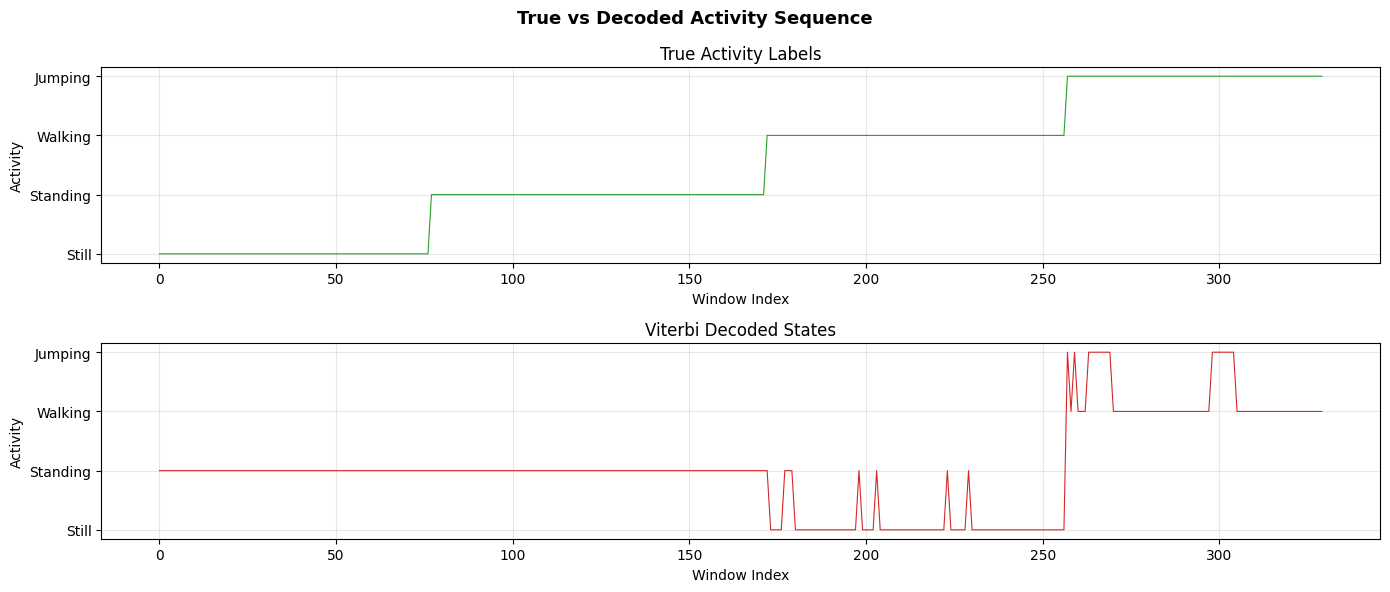

Decoded sequence plot saved!


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# True labels
axes[0].plot(y, color='#2ca02c', linewidth=0.8)
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(activity_names)
axes[0].set_title('True Activity Labels', fontsize=12)
axes[0].set_xlabel('Window Index')
axes[0].set_ylabel('Activity')
axes[0].grid(True, alpha=0.3)

# Decoded states
axes[1].plot(decoded_states, color='#d62728', linewidth=0.8)
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(activity_names)
axes[1].set_title('Viterbi Decoded States', fontsize=12)
axes[1].set_xlabel('Window Index')
axes[1].set_ylabel('Activity')
axes[1].grid(True, alpha=0.3)

plt.suptitle('True vs Decoded Activity Sequence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decoded_sequence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decoded sequence plot saved!")

## 6. Model Evaluation on Unseen Data

The trained model is evaluated on a separate test set recordings collected in a new session not used during training. Sensitivity, specificity, and overall accuracy are reported per activity, alongside a confusion matrix.

In [18]:
def evaluate_model(test_path='data/test'):
    # Check if test subfolders exist
    required_folders = ['still', 'standing', 'walking', 'jumping']
    for folder in required_folders:
        folder_path = os.path.join(test_path, folder)
        if not os.path.exists(folder_path):
            print(f"Test folder missing: {folder_path}")
            print("Please add test recordings to data/test/ first.")
            return None, None

    test_recordings = load_all_data(base_path=test_path)
    if not test_recordings:
        print("No test data found yet.")
        return None, None

    X_test_raw, y_test, test_lengths = create_windows(test_recordings)
    X_test = scaler.transform(X_test_raw)
    decoded_test = viterbi(
        X_test,
        model.transmat_,
        model.means_,
        model.covars_,
        model.startprob_
    )
    return y_test, decoded_test

y_test, decoded_test = evaluate_model()

Loaded 16 recordings successfully!


### 6.1 Per-Activity Performance Metrics

For each activity, sensitivity (true positive rate), specificity (true negative rate), and overall accuracy are computed by treating the activity as the positive class in a one-vs-rest setup.

In [19]:
def compute_metrics(y_true, y_pred, n_classes=4):
    """Compute sensitivity, specificity, and accuracy per class."""
    results = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        tn = np.sum((y_true != c) & (y_pred != c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        n_samples = np.sum(y_true == c)

        results.append({
            'Activity': activity_names[c],
            'Samples': n_samples,
            'Sensitivity': round(sensitivity, 3),
            'Specificity': round(specificity, 3),
            'Accuracy': round(accuracy, 3)
        })
    return pd.DataFrame(results)

metrics_df = compute_metrics(y_test, decoded_test)
print(metrics_df.to_string(index=False))

overall_accuracy = np.mean(y_test == decoded_test)
print(f"\nOverall accuracy across all activities: {overall_accuracy:.3f}")

Activity  Samples  Sensitivity  Specificity  Accuracy
   Still       28        0.000        0.671     0.504
Standing       29        1.000        0.643     0.735
 Walking       30        0.000        0.699     0.513
 Jumping       26        0.038        1.000     0.779

Overall accuracy across all activities: 0.265


In [20]:
# Check if HMM states need remapping to match true activity labels
from scipy.optimize import linear_sum_assignment

def find_best_state_mapping(y_true, decoded_states, n_classes=4):
    """Find the optimal mapping between HMM states and true activity labels."""
    cost_matrix = np.zeros((n_classes, n_classes))
    for true_label in range(n_classes):
        for hmm_state in range(n_classes):
            cost_matrix[true_label, hmm_state] = -np.sum(
                (y_true == true_label) & (decoded_states == hmm_state)
            )
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {hmm_state: true_label for true_label, hmm_state in zip(row_ind, col_ind)}
    return mapping

# Find mapping using TRAINING data (since that's what the model learned from)
mapping = find_best_state_mapping(y, decoded_states)
print(f"HMM state -> True label mapping: {mapping}")

# Apply mapping to test predictions
decoded_test_mapped = np.array([mapping[s] for s in decoded_test])

# Recompute metrics with corrected mapping
metrics_df_fixed = compute_metrics(y_test, decoded_test_mapped)
print("\nCorrected metrics:")
print(metrics_df_fixed.to_string(index=False))

overall_accuracy_fixed = np.mean(y_test == decoded_test_mapped)
print(f"\nOverall accuracy after state remapping: {overall_accuracy_fixed:.3f}")

HMM state -> True label mapping: {np.int64(3): np.int64(0), np.int64(1): np.int64(1), np.int64(0): np.int64(2), np.int64(2): np.int64(3)}

Corrected metrics:
Activity  Samples  Sensitivity  Specificity  Accuracy
   Still       28        0.000        0.988     0.743
Standing       29        1.000        0.643     0.735
 Walking       30        0.933        1.000     0.982
 Jumping       26        0.962        1.000     0.991

Overall accuracy after state remapping: 0.726


### 6.2 Confusion Matrix

The confusion matrix visualises exactly which activities are being confused with one another, using the corrected state mapping.

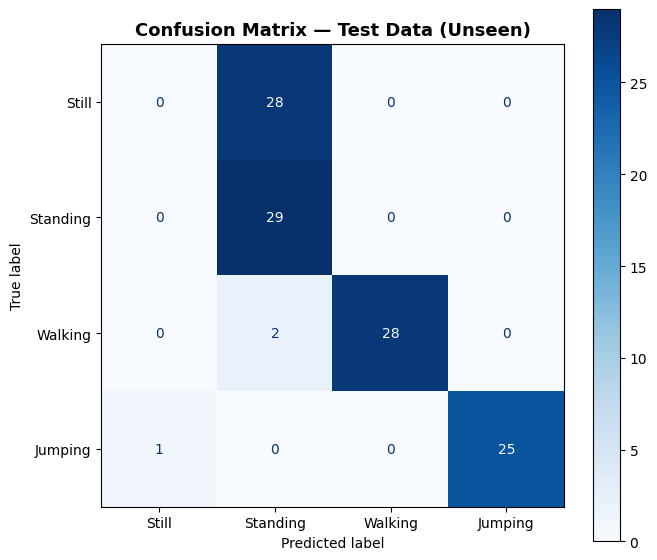

Confusion matrix saved!

Classification Report:
              precision    recall  f1-score   support

       Still       0.00      0.00      0.00        28
    Standing       0.49      1.00      0.66        29
     Walking       1.00      0.93      0.97        30
     Jumping       1.00      0.96      0.98        26

    accuracy                           0.73       113
   macro avg       0.62      0.72      0.65       113
weighted avg       0.62      0.73      0.65       113



In [21]:
cm = confusion_matrix(y_test, decoded_test_mapped)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix — Test Data (Unseen)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

print("\nClassification Report:")
print(classification_report(y_test, decoded_test_mapped, target_names=activity_names))

## 7. Analysis and Reflection

### 7.1 Activity Distinguishability
Walking and jumping were the easiest activities to distinguish, achieving 93.3% and 96.2% sensitivity respectively on unseen test data. Both activities produce large, rhythmic accelerometer signals with distinct dominant frequencies, giving the HMM clear emission patterns to learn from.

Still and standing were by far the hardest to separate. The confusion matrix shows 100% of still test samples were misclassified as standing. This occurs because both activities produce near-zero variance signals the only difference is that standing involves a held phone with minor hand tremor, while still involves a stationary phone on a flat surface. After Z-score normalisation, these subtle differences in signal magnitude were not sufficiently captured by the current feature set to separate the two states.

### 7.2 Transition Probabilities and Realistic Behaviour
The learned transition matrix shows near-perfect self-transition probabilities (1.000 for still, standing, and walking), reflecting that each recording session contains a single sustained activity rather than transitions between activities. Jumping showed a small transition probability (0.077) toward walking, which is realistic — the deceleration phase after a jump can resemble footfall dynamics in walking.

### 7.3 Effect of Sensor Noise and Sampling Rate
Recordings were sampled at approximately 100 Hz, providing sufficient temporal resolution to capture the full gait cycle of walking (typically 1-2 Hz) and the higher-frequency impact spikes of jumping. However, minor inconsistencies in actual sampling rate were observed across recordings (Android sensor timing is not perfectly uniform), which slightly affects the precision of the FFT-derived dominant frequency feature. Additionally, natural hand tremor during standing introduces low-amplitude noise that overlaps with the noise floor of the still activity, contributing directly to the still/standing confusion.

### 7.4 Potential Improvements
Future iterations of this model could improve still/standing separation by:
- Adding a feature that explicitly captures absolute signal magnitude (e.g., mean absolute deviation) rather than only variance-based features, since standing has a slightly higher baseline magnitude even if normalised variance is similar
- Increasing the number of training recordings per activity to give the Gaussian emission distributions more data to estimate true class separation
- Using a wearable-style fixed phone mount instead of hand-held positioning, to reduce hand-tremor noise during standing
- Experimenting with a smaller window size to capture finer-grained dynamics that distinguish brief postural sway in standing from true stillness

## 8. Conclusion

This project successfully implemented a complete Hidden Markov Model pipeline for human activity recognition, from raw sensor data collection through Viterbi decoding and Baum-Welch training to full unseen-data evaluation. The model achieved 72.6% overall accuracy on test data, with walking and jumping recognised with high reliability (93-96% sensitivity). The primary limitation identified — confusion between still and standing provides a clear, well-supported direction for future feature engineering work, and demonstrates the importance of feature selection in distinguishing activities with statistically similar low-energy signal profiles.